In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md
import pandas as pd
from scipy.stats import pearsonr

In [ ]:
def count_molecules(pdb_file):
    """
    Count the number of molecules in a PDB file using MDTraj.
    """
    traj = md.load(pdb_file)
    topology = traj.topology
    molecules = list(topology.find_molecules())
    return len(molecules)

def calc_density(density_arr):
    return np.mean(density_arr)

def calc_cavg_density(density_arr):
    """
    Calculate the cumulative average of the density.
    """
    cavg_density = np.cumsum(density_arr) / np.arange(1, len(density_arr) + 1)
    return cavg_density

def calc_deltaH_vap(pe_l, pe_g, n_molecules, temp):
    R = 8.31446261815324/1000 # kJ/mol/K
    deltaH_vap = np.mean(pe_g) - np.mean(pe_l)/n_molecules + R*temp
    deltaH_vap = deltaH_vap / 4.184 # to kcal/mol
    return deltaH_vap

def calc_cavg_deltaH_vap(pe_l, pe_g, n_molecules, temp):
    """
    Calculate the cumulative average of the enthalpy of vapourisation.
    """
    R = 8.31446261815324/1000 # kJ/mol/K
    cavg_pe_g = np.cumsum(pe_g) / np.arange(1, len(pe_g) + 1)
    cavg_pe_l = np.cumsum(pe_l) / np.arange(1, len(pe_l) + 1)
    cavg_deltaH_vap = cavg_pe_g - cavg_pe_l / n_molecules + R * temp
    cavg_deltaH_vap /= 4.184  # to kcal/mol
    return cavg_deltaH_vap

def plot_cavg_density(cavg_density, equil_time, smiles):
    dt = 0.002/1000 # timestep in ns/step
    sampling_freq = 5000 # saved every 10 ps
    time = np.arange(len(cavg_density)) * dt * sampling_freq + equil_time 
    plt.figure(figsize=(4.5,3.5))
    plt.hlines(y=np.array(cavg_density)[-1],xmin=min(time),xmax=max(time),color='tab:orange', lw=3, alpha=1)
    plt.plot(time, cavg_density, lw=3)
    plt.xlabel("Time (ns)")
    plt.ylabel(r"Density (g/mL)")
    plt.title(smiles)
    plt.tight_layout()
    plt.show()

def plot_cavg_deltaH_vap(cavg_deltaH_vap, equil_time, smiles):
    dt = 0.002/1000 # timestep in ns/step
    sampling_freq = 5000 # saved every 10 ps
    time = np.arange(len(cavg_deltaH_vap)) * dt * sampling_freq + equil_time 
    plt.figure(figsize=(4.5,3.5))
    plt.hlines(y=np.array(cavg_deltaH_vap)[-1],xmin=min(time),xmax=max(time),color='tab:orange', lw=3, alpha=1)
    plt.plot(time, cavg_deltaH_vap, lw=3)
    plt.xlabel("Time (ns)")
    plt.ylabel(r"$\Delta H_{\mathrm{vap}}$ (kcal/mol)")
    plt.title(smiles)
    plt.tight_layout()
    plt.show()

def calc_rmse(y_calc, y_exp):
    y_calc = np.array(y_calc)
    y_exp = np.array(y_exp)
    return np.sqrt(np.mean((y_exp - y_calc)** 2))

def analyse_vapour_sim(ff_name,enth_vap_df):
    """
    Read simulation results and calculate ensemble averages
    and cumulative ensemble averages of liquid phase mass 
    density and enthalpy of vapourisation. 
    """
    # discard 5 ns, frame save every 5000 steps (10 ps)
    equil_time = 5 
    equil_steps = int(2500000 / 5000) 

    density_list = []
    deltaH_vap_list = []

    for _,row in enth_vap_df.iterrows():

        smiles = row["SMILES"]
        n_molecules = row["n_molecules"]

        if not (ff_name == "gaff" and smiles in ["C1CCCCC1", "CC(O)=O"]):

            temp_DeltaH_vap = row["temp_DeltaH_vap"]
            temp_density = row["temp_density"]

            # Get logged simulation data for liquid and gas phase at temp=temp_DeltaH_vap
            liquid_df = pd.read_csv(f"simulations/{ff_name}/vapourisation_liquid/{smiles}_{temp_DeltaH_vap}K.log")
            gas_df = pd.read_csv(f"simulations/{ff_name}/vapourisation_gas/{smiles}_{temp_DeltaH_vap}K.log")

            # Remove frames from equilibration phase
            liquid_df = liquid_df[equil_steps:]
            gas_df = gas_df[equil_steps:]

            # Get data to analyse
            pe_l = liquid_df['Potential Energy (kJ/mole)'].values
            pe_g = gas_df['Potential Energy (kJ/mole)'].values

            # Calc ensemble average
            deltaH_vap = calc_deltaH_vap(pe_l, pe_g, n_molecules, temp_DeltaH_vap)
            deltaH_vap_list.append(deltaH_vap)

            # Calc and plot cumulative ensemble averages
            cavg_deltaH_vap = calc_cavg_deltaH_vap(pe_l, pe_g, n_molecules, temp_DeltaH_vap)
            plot_cavg_deltaH_vap(cavg_deltaH_vap, equil_time, smiles)

            # Get logged simulation data for liquid phase at temp=temp_density
            liquid_df = pd.read_csv(f"simulations/{ff_name}/vapourisation_liquid/{smiles}_{temp_density}K.log")

            # Remove frames from equilibration phase
            liquid_df = liquid_df[equil_steps:]

            # Calculate density ensemble average
            density_l = liquid_df['Density (g/mL)'].values
            density = calc_density(density_l)
            density_list.append(density)

            # Calc and plot cumulative ensemble averages
            cavg_density = calc_cavg_density(density_l)
            plot_cavg_density(cavg_density, equil_time, smiles)

        else:
            
            deltaH_vap_list.append(np.nan)
            density_list.append(np.nan)

    enth_vap_df["density_sim"] = density_list
    enth_vap_df["DeltaH_vap_sim"] = deltaH_vap_list

    return enth_vap_df

def boostrap_rmse_ci(arr_sim, arr_exp, n_samples=10000):
    rmse_list = []
    for i in range(n_samples):
        indices = np.arange(0,len(arr_sim),1)
        resampled_indices = np.random.choice(indices, size=len(indices), replace=True)
        arr_sim_sample = arr_sim[resampled_indices]
        arr_exp_sample = arr_exp[resampled_indices]
        rmse = calc_rmse(arr_sim_sample, arr_exp_sample)
        rmse_list.append(rmse)
    lower = np.percentile(rmse_list, 2.5)
    upper = np.percentile(rmse_list, 97.5)
    return lower, upper

def boostrap_r_ci(arr_sim, arr_exp, n_samples=10000):
    r_list = []
    for i in range(n_samples):
        indices = np.arange(0,len(arr_sim),1)
        resampled_indices = np.random.choice(indices, size=len(indices), replace=True)
        arr_sim_sample = arr_sim[resampled_indices]
        arr_exp_sample = arr_exp[resampled_indices]
        r = pearsonr(arr_sim_sample, arr_exp_sample)[0]
        r_list.append(r)
    lower = np.percentile(r_list, 2.5)
    upper = np.percentile(r_list, 97.5)
    return lower, upper

def score_ff(enth_vap_df, property_name):
    """
    Calculate RMSE and r between experimental and
    calculated data (dH_vap or r) across small
    molecule benchmark set.
    """
    # Define molecules used for Garnet training
    training_molecules = ["benzene","water","methanol"]
    
    # Split into train and validation data
    train_mol_idx = enth_vap_df["name"].isin(training_molecules).values
    val_mol_idx = ~enth_vap_df["name"].isin(training_molecules).values

    if property_name == "dhvap":
        obs_sim = enth_vap_df["DeltaH_vap_sim"].values
        obs_exp = enth_vap_df["DeltaH_vap_exp"].values
    elif property_name == "rho":
        obs_sim = enth_vap_df["density_sim"].values
        obs_exp = enth_vap_df["density_exp"].values
    else:
        raise ValueError(f"Input property should be 'dhvap' or 'rho'")

    # Calc RMSE over train and val data separately
    rmse_train = calc_rmse(obs_sim[train_mol_idx], obs_exp[train_mol_idx])
    rmse_val = calc_rmse(obs_sim[val_mol_idx], obs_exp[val_mol_idx])

    # Calc r over train and val data separately
    r_train = pearsonr(obs_sim[train_mol_idx], obs_exp[train_mol_idx])[0]
    r_val = pearsonr(obs_sim[val_mol_idx], obs_exp[val_mol_idx])[0]

    # Boostrap RMSE confidence intervals
    # Only val since train set too small 
    ci_lower_rmse_val, ci_upper_rmse_val = boostrap_rmse_ci(obs_sim[val_mol_idx], obs_exp[val_mol_idx])

    # Boostrap r confidence intervals
    # Only val since train set too small 
    ci_lower_r_val, ci_upper_r_val = boostrap_r_ci(obs_sim[val_mol_idx], obs_exp[val_mol_idx])

    return {
        "rmse": {
            "train": rmse_train,
            "val": rmse_val,
            "val_ci_95": (ci_lower_rmse_val, ci_upper_rmse_val),
        },
        "r": {
            "train": r_train,
            "val": r_val,
            "val_ci_95": (ci_lower_r_val, ci_upper_r_val),
        }
    }

In [3]:
# Read experimental data
enth_vap_df = pd.read_csv("condensed_data/exp_data/density_hvap_benchmark.csv")

# Convert temperatures to K
enth_vap_df['temp_DeltaH_vap'] = enth_vap_df['T_vap_C'] + 273.15
enth_vap_df['temp_density'] = enth_vap_df['T_density_C'] + 273.15
enth_vap_df = enth_vap_df.drop(columns=["T_density_C", "T_vap_C", "n_atoms", "Notes"])

# Get number of molecules in each simulation box
n_molecules_list = []
for index,row in enth_vap_df.iterrows():
    smiles = row["SMILES"]
    n_molecules = count_molecules(f"condensed_data/starting_structures/vapourisation_liquid_{smiles}.pdb")
    n_molecules_list.append(n_molecules)
enth_vap_df["n_molecules"] = n_molecules_list

enth_vap_df.head()

,name,density_exp,DeltaH_vap_exp,SMILES,temp_DeltaH_vap,temp_density,n_molecules
0,benzene,0.8765,8.150,c1ccccc1,293.15,293.15,182
1,water,1.0000,10.560,O,293.15,293.15,903
2,methanol,0.7920,8.995,CO,293.15,293.15,402
3,butane,0.6020,5.020,CCCC,272.65,272.65,168
4,cyclohexane,0.7740,7.890,C1CCCCC1,298.15,298.15,150


garnet


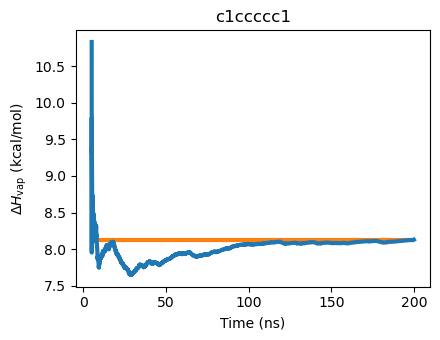

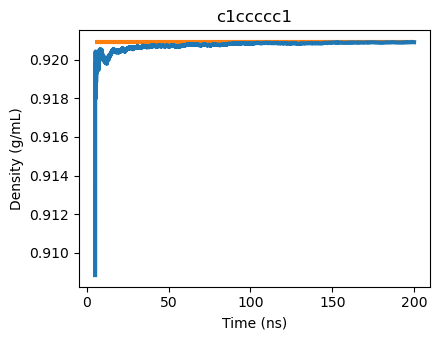

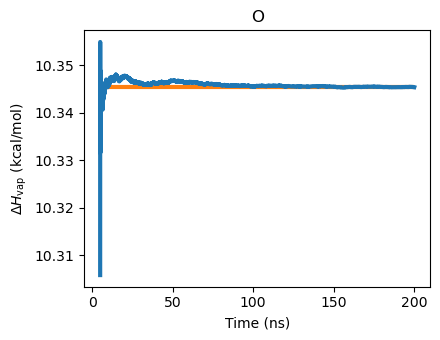

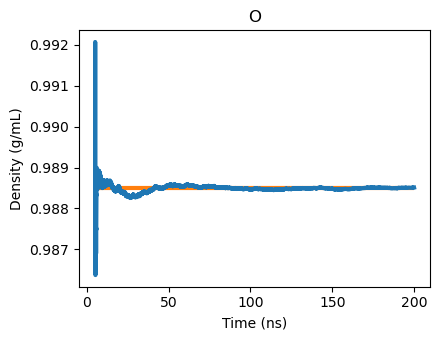

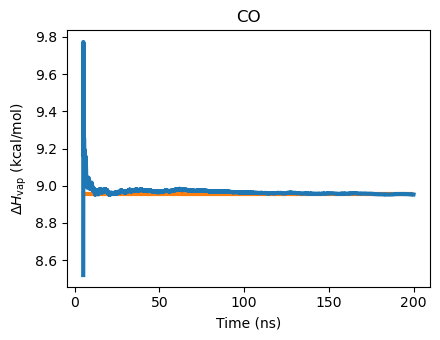

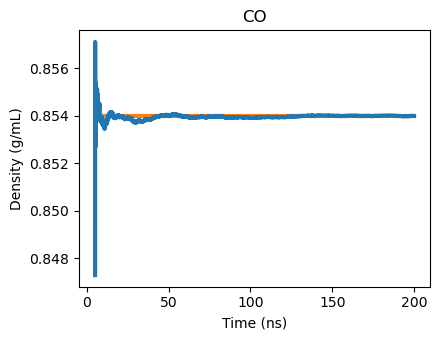

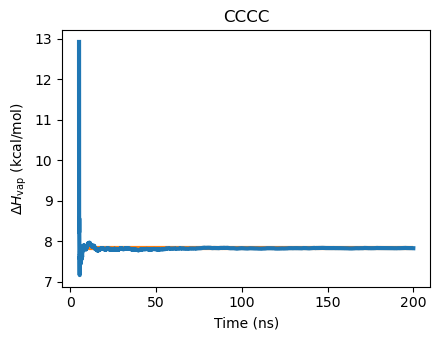

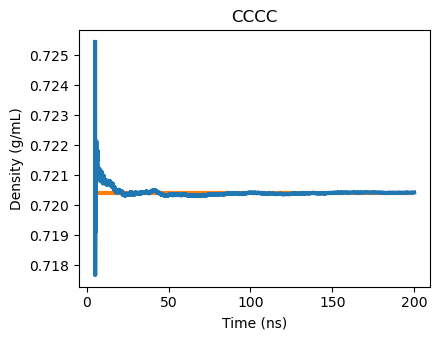

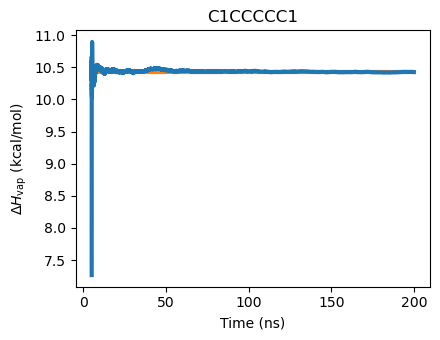

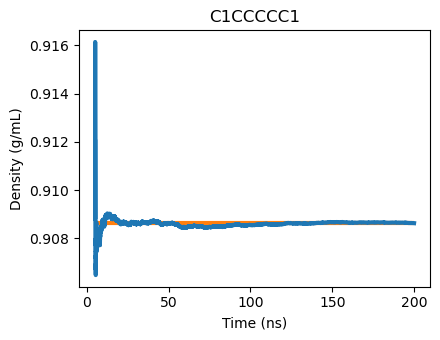

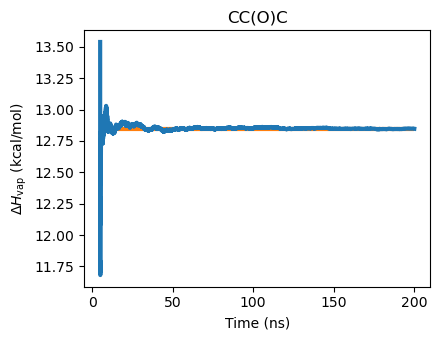

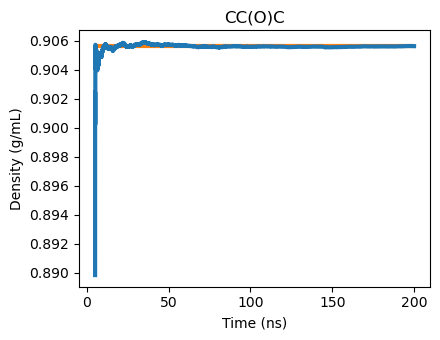

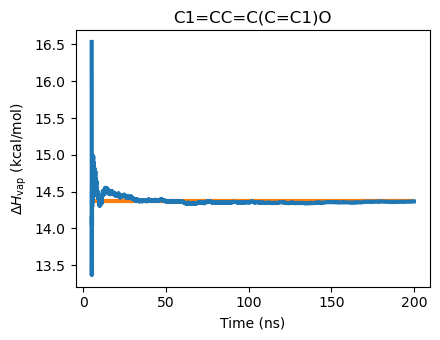

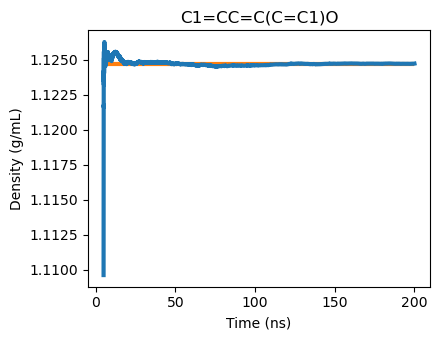

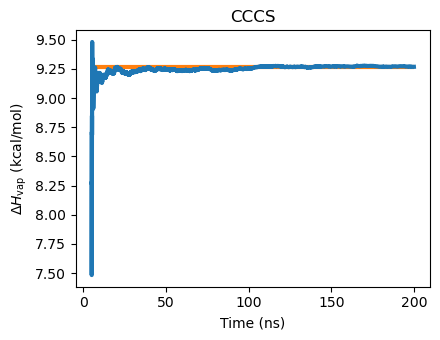

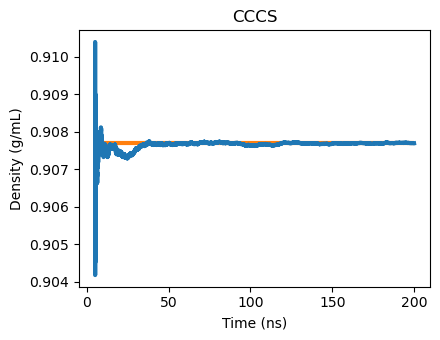

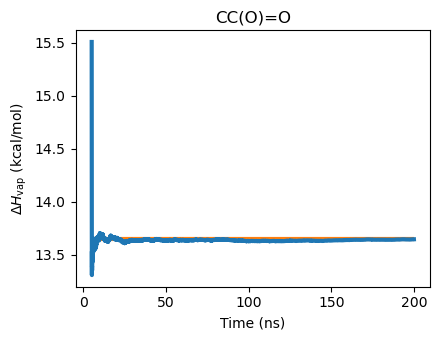

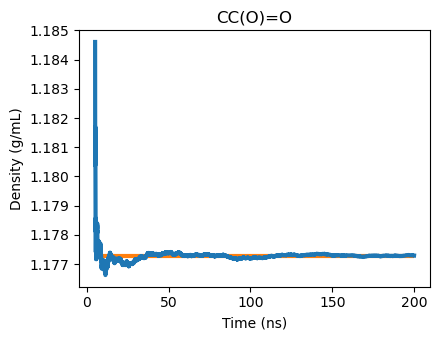

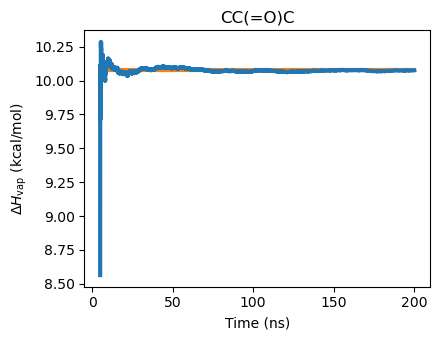

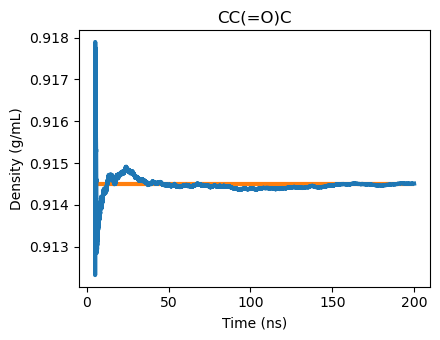

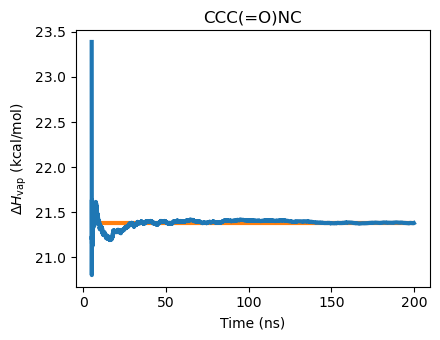

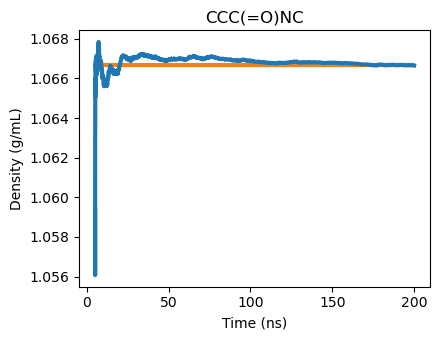

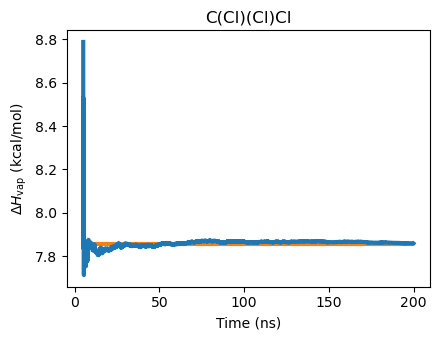

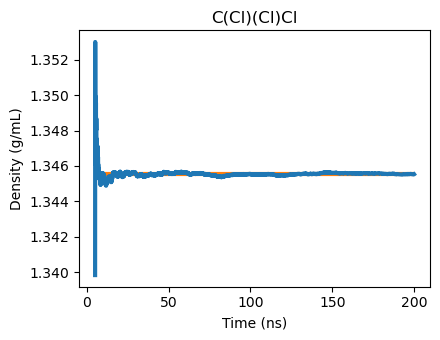

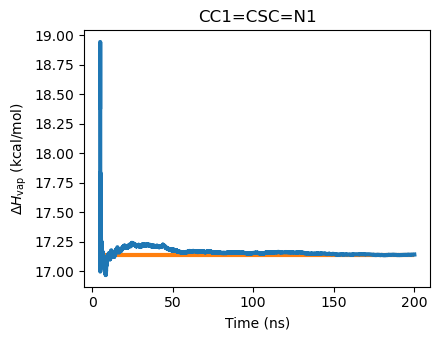

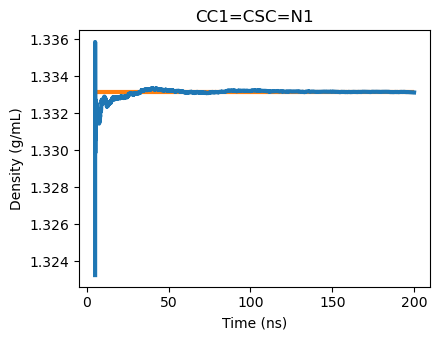

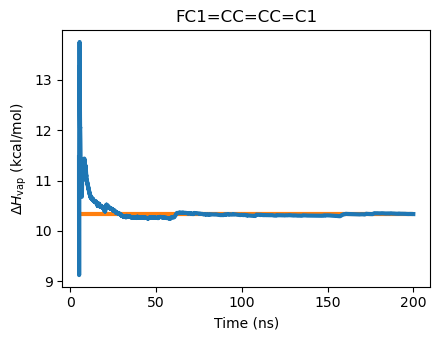

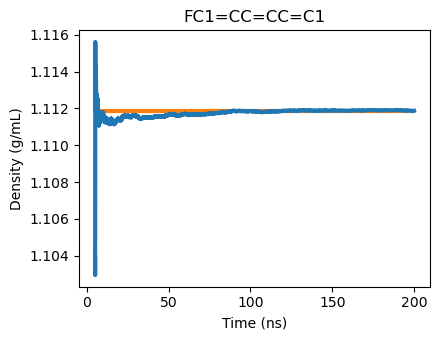

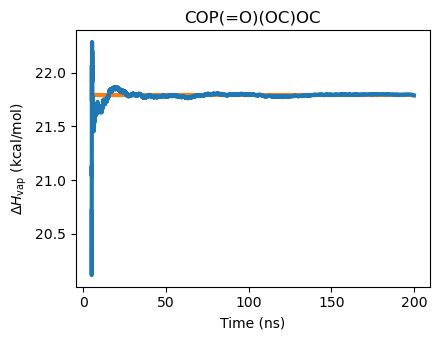

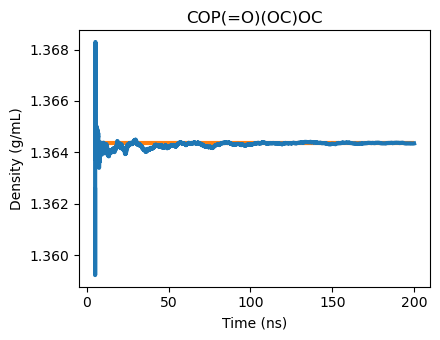

openff


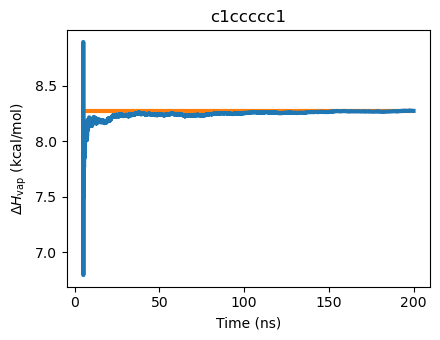

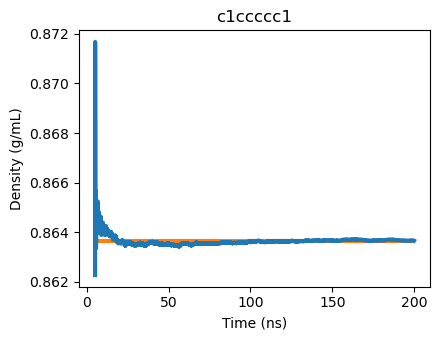

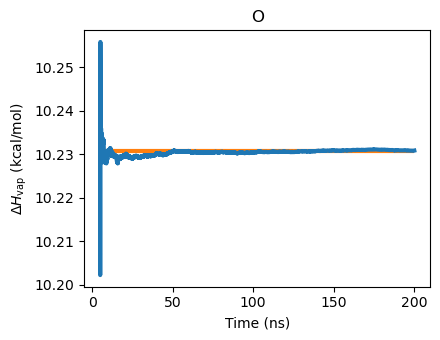

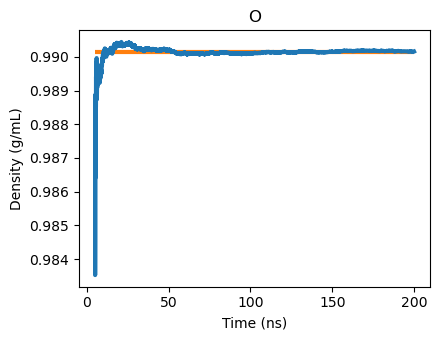

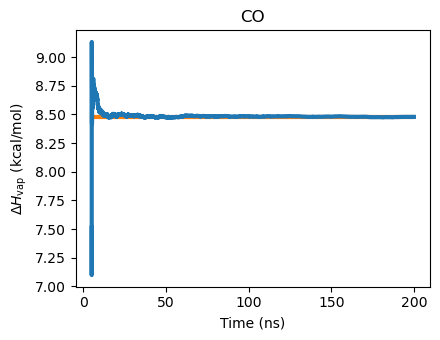

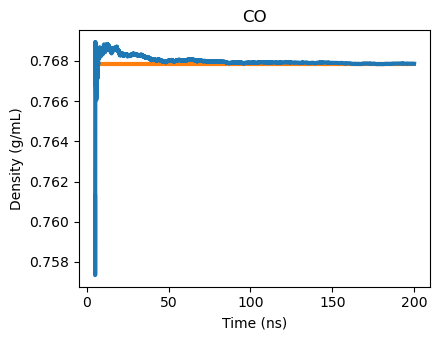

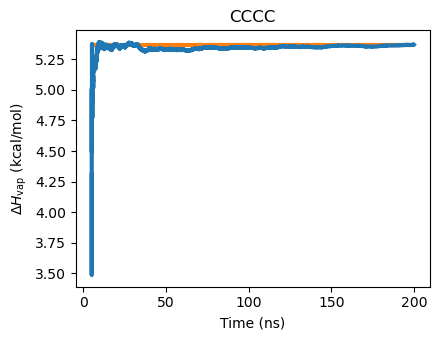

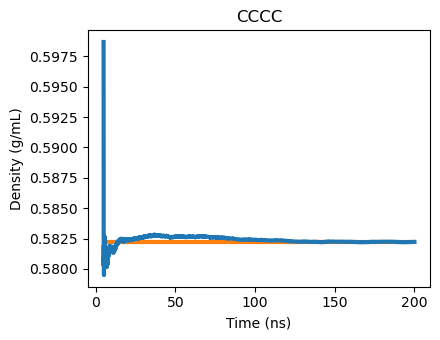

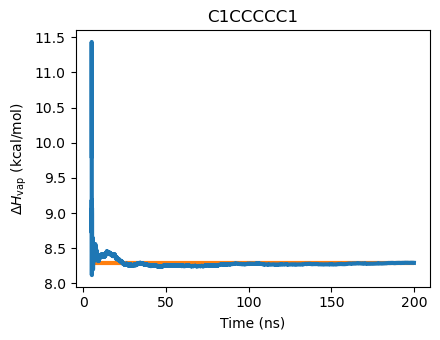

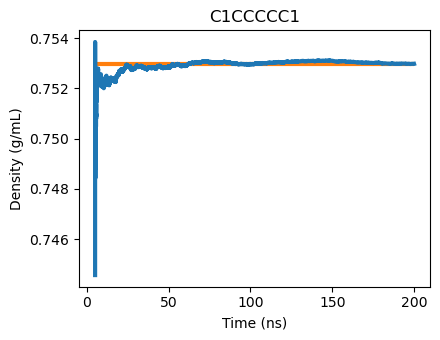

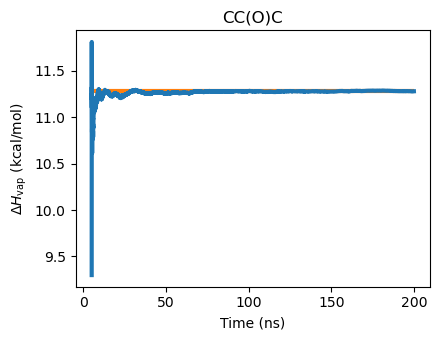

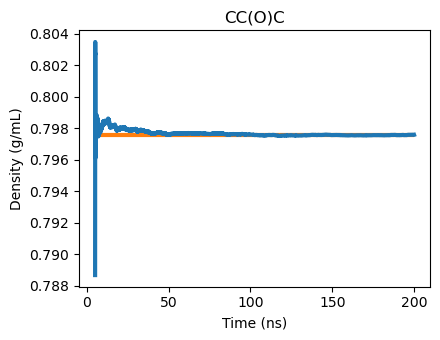

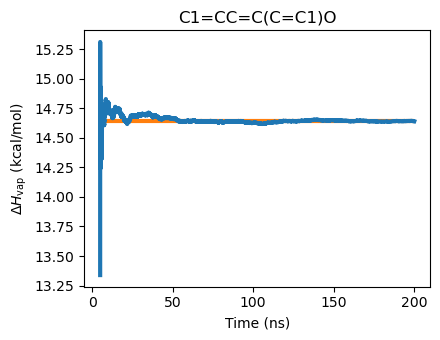

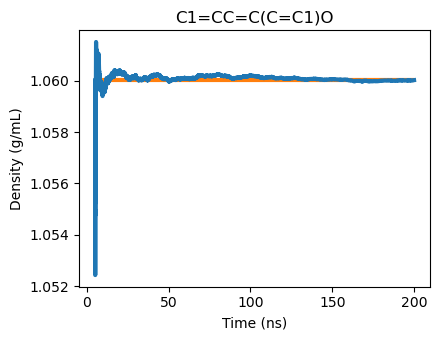

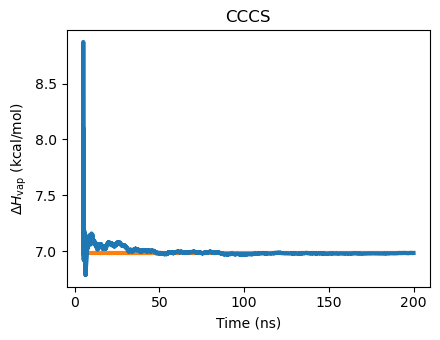

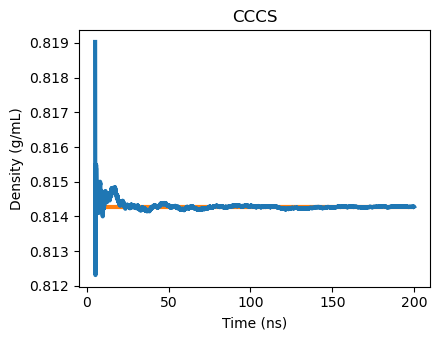

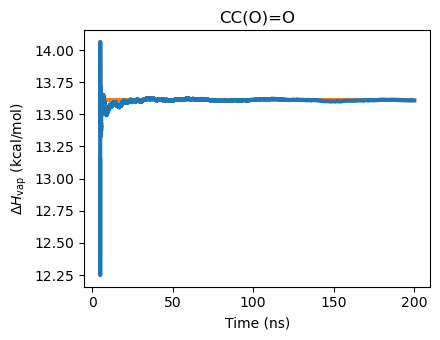

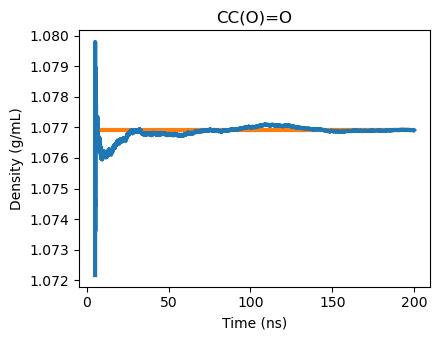

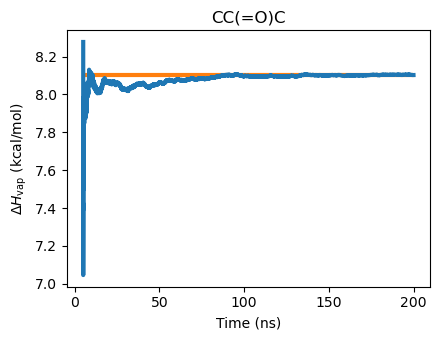

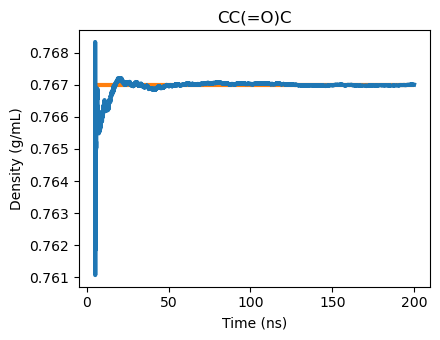

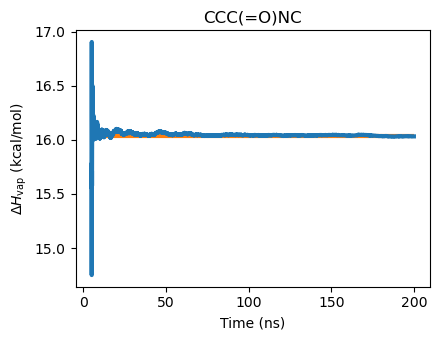

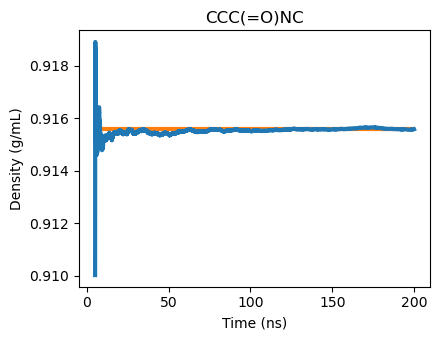

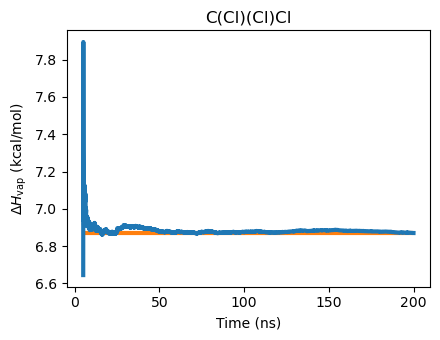

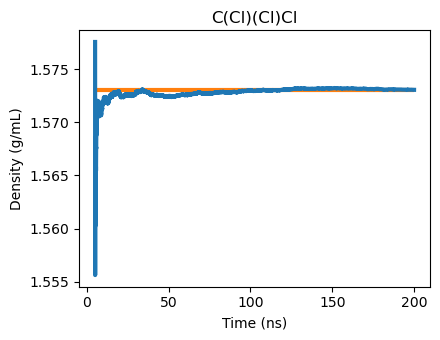

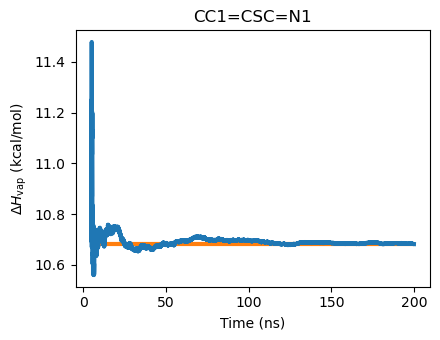

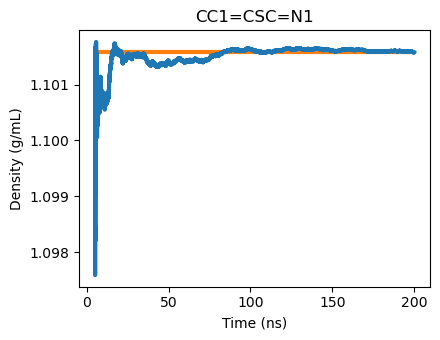

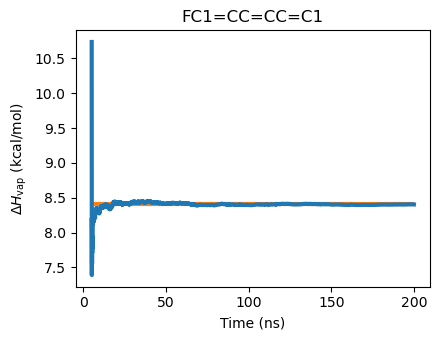

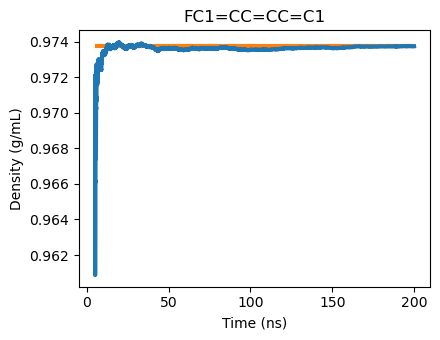

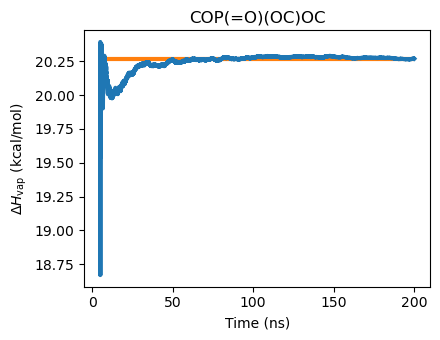

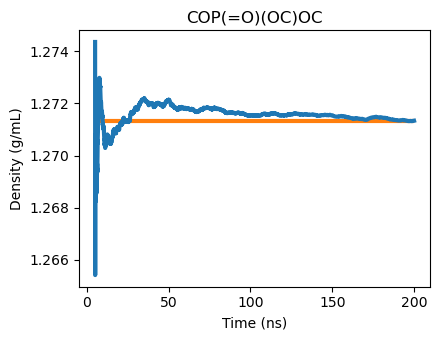

gaff


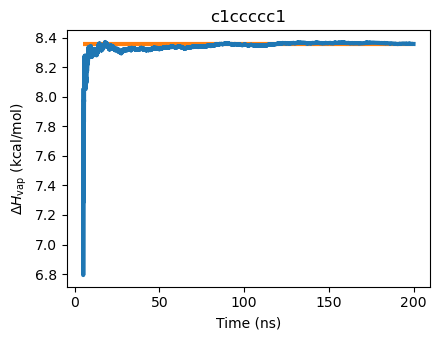

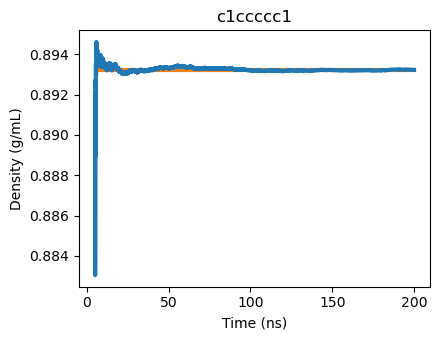

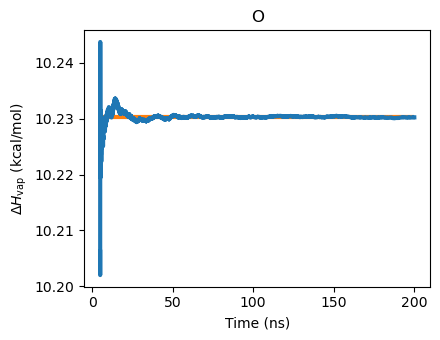

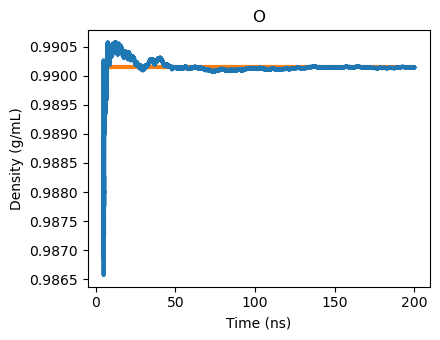

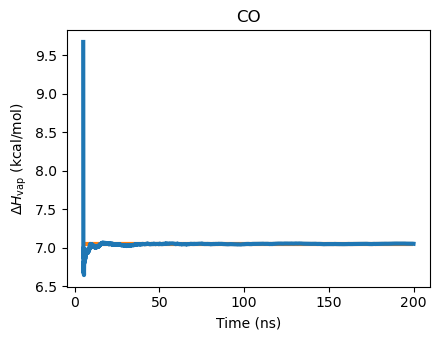

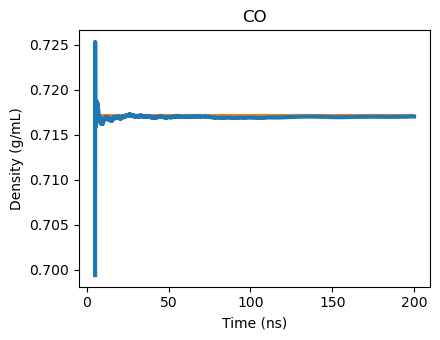

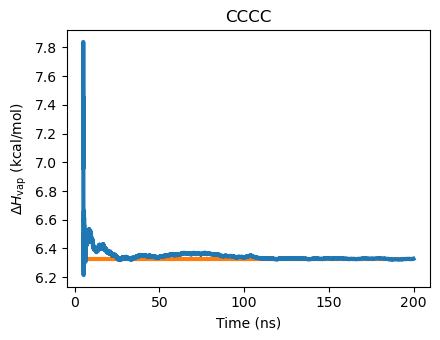

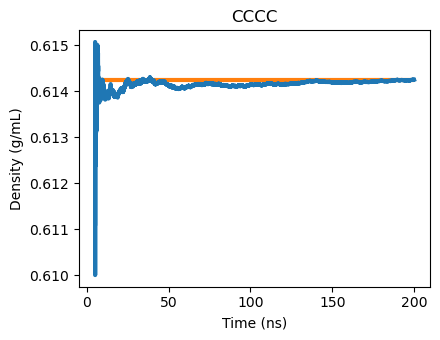

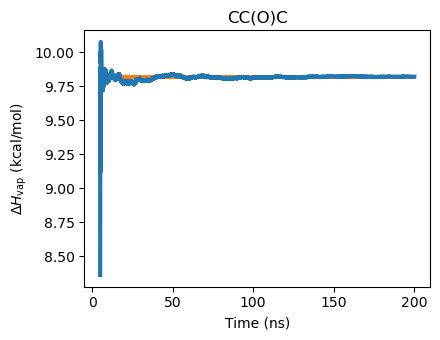

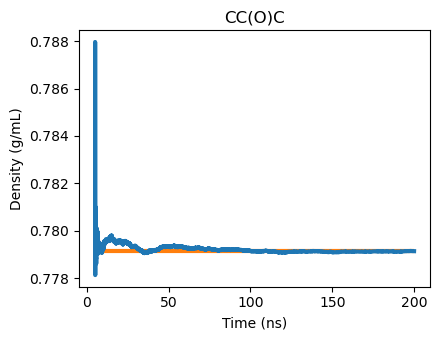

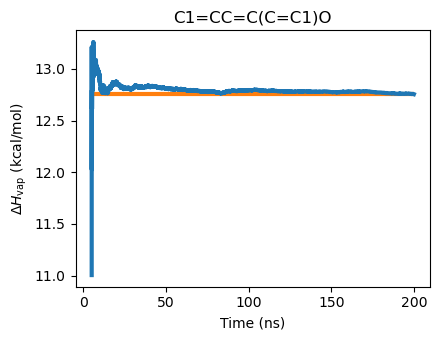

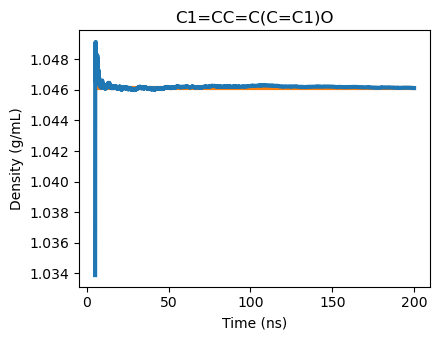

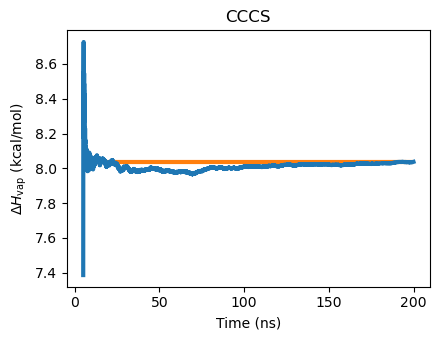

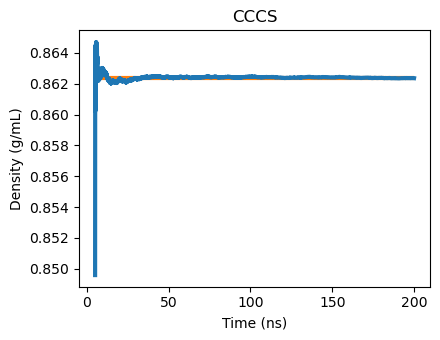

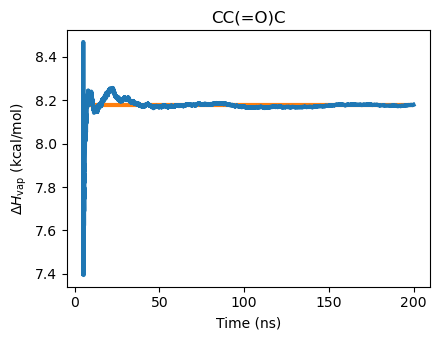

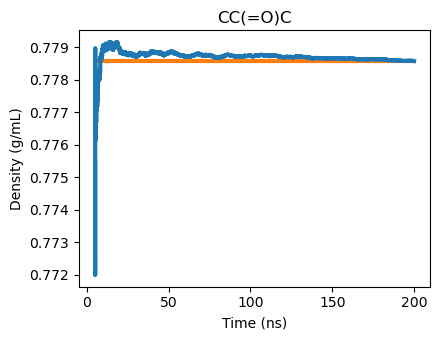

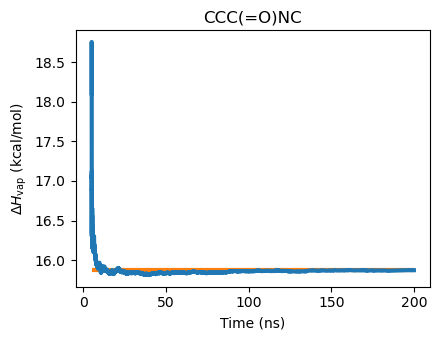

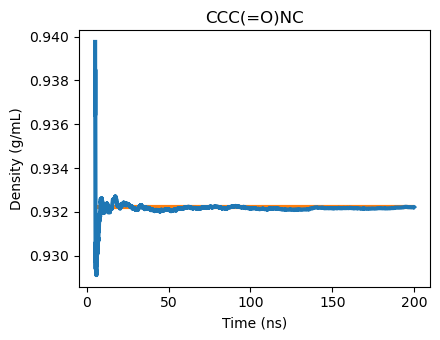

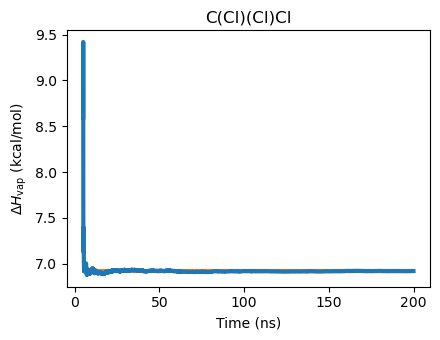

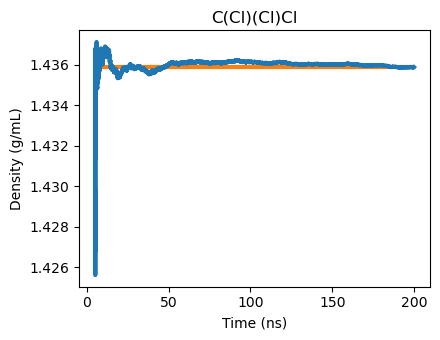

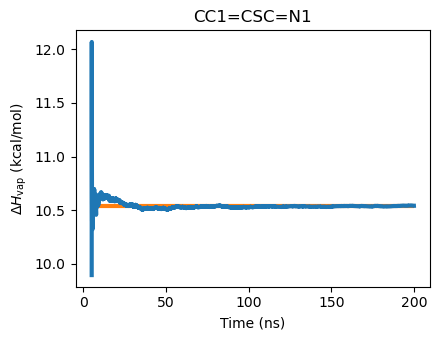

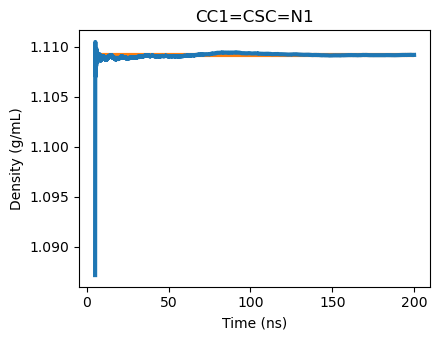

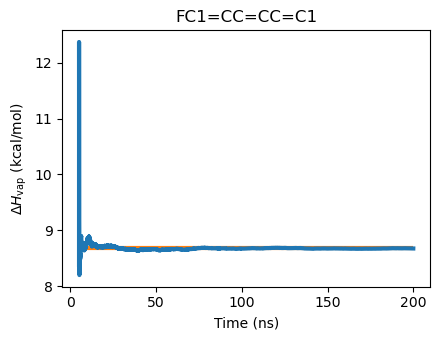

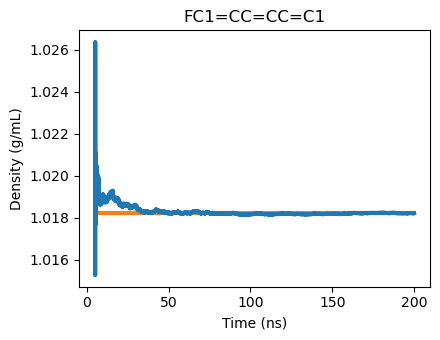

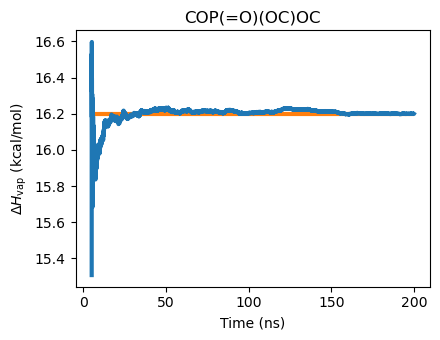

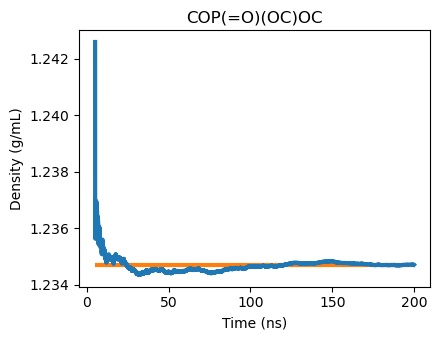

In [ ]:
# Analyse simulation data and calculate ensemble-averaged density and enthalpy of vapourisation 
# Run analysis for all force fields
garnet_enth_vap_df = analyse_vapour_sim("garnet",enth_vap_df.copy(deep=True)) 
openff_enth_vap_df = analyse_vapour_sim("openff",enth_vap_df.copy(deep=True))
gaff_enth_vap_df = analyse_vapour_sim("gaff",enth_vap_df.copy(deep=True))

In [ ]:
# Calculate RMSE and r between exp and sim data 

# Garnet
eval_garnet_rho = score_ff(garnet_enth_vap_df, "rho")
eval_garnet_dhvap = score_ff(garnet_enth_vap_df, "dhvap")

# OpenFF
eval_openff_rho = score_ff(openff_enth_vap_df, "rho")
eval_openff_dhvap = score_ff(openff_enth_vap_df, "dhvap")

# GAFF
eval_gaff_rho = score_ff(gaff_enth_vap_df.dropna(), "rho")
eval_gaff_dhvap = score_ff(gaff_enth_vap_df.dropna(), "dhvap")

In [38]:
# Split DataFrames into training and validation data (for plotting)

train_smiles = ["benzene","water","methanol"]

garnet_enth_vap_df['train'] = garnet_enth_vap_df.name.isin(train_smiles)
openff_enth_vap_df['train'] = openff_enth_vap_df.name.isin(train_smiles)
gaff_enth_vap_df['train'] = gaff_enth_vap_df.name.isin(train_smiles)

garnet_train = garnet_enth_vap_df[garnet_enth_vap_df["train"]]
garnet_val = garnet_enth_vap_df[~garnet_enth_vap_df["train"]]

openff_train = openff_enth_vap_df[openff_enth_vap_df["train"]]
openff_val = openff_enth_vap_df[~openff_enth_vap_df["train"]]

gaff_train = gaff_enth_vap_df[gaff_enth_vap_df["train"]]
gaff_val = gaff_enth_vap_df[~gaff_enth_vap_df["train"]]

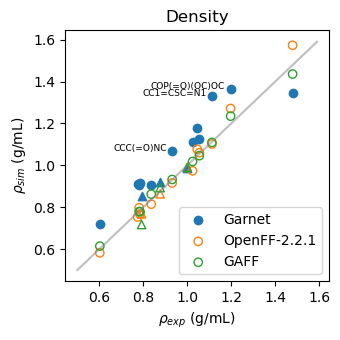

In [ ]:
# Plot predicted density as function of experimental density

plt.figure(figsize=(3.5,3.5))

# Plot Garnet results, indicate training data with ^
plt.scatter(garnet_train["density_exp"],garnet_train["density_sim"], marker="^", color="tab:blue")
plt.scatter(garnet_val["density_exp"],garnet_val["density_sim"], marker="o", color="tab:blue", label="Garnet")

# Indicate SMILES of Garnet outliers
outlier_inds = [10, 12, 14]
outlier_text_x_coords = {10:-42.5, 12:-50, 14:-57.5}
for i in outlier_inds:
    plt.annotate(
        garnet_val.loc[i]["SMILES"],
        (garnet_val.loc[i]["density_exp"], garnet_val.loc[i]["density_sim"]),
        xytext=(outlier_text_x_coords[i], 0),           
        textcoords="offset points",
        fontsize=6.5
    )

# Plot OpenFF results
plt.scatter(openff_train["density_exp"],openff_train["density_sim"], marker="^", color="tab:orange", facecolors="none")
plt.scatter(openff_val["density_exp"],openff_val["density_sim"], marker="o", color="tab:orange", facecolors="none", label="OpenFF-2.2.1")

# Plot GAFF results
plt.scatter(gaff_train["density_exp"],gaff_train["density_sim"], marker="^", facecolors="none", color="tab:green")
plt.scatter(gaff_val["density_exp"],gaff_val["density_sim"], marker="o", facecolors="none", color="tab:green", label="GAFF")

# Plot diagonal
plt.plot(np.arange(0.5,1.6,0.01),np.arange(0.5,1.6,0.01), color="grey",alpha=0.5)

plt.xlabel(r"$\rho_{exp}$ (g/mL)")
plt.ylabel(r"$\rho_{sim}$ (g/mL)")

plt.title("Density")
plt.legend()
plt.tight_layout()
plt.savefig("figures/density_benchmark.pdf")

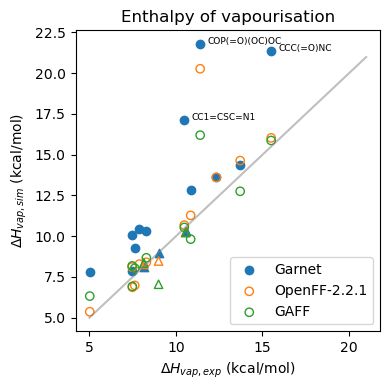

In [60]:
plt.figure(figsize=(4,4))

# Plot Garnet results, indicate training data with ^
plt.scatter(garnet_train["DeltaH_vap_exp"], garnet_train["DeltaH_vap_sim"], marker="^", color="tab:blue")
plt.scatter(garnet_val["DeltaH_vap_exp"], garnet_val["DeltaH_vap_sim"], marker="o", color="tab:blue", label="Garnet")

# Indicate SMILES of Garnet outliers
outlier_inds = [10, 12, 14]
for i in outlier_inds:
    plt.annotate(
        garnet_val.loc[i]["SMILES"],
        (garnet_val.loc[i]["DeltaH_vap_exp"], garnet_val.loc[i]["DeltaH_vap_sim"]),
        xytext=(5, 0),           
        textcoords="offset points",
        fontsize=6.5
    )

# Plot OpenFF results
plt.scatter(openff_train["DeltaH_vap_exp"], openff_train["DeltaH_vap_sim"], marker="^", color="tab:orange", facecolors="none")
plt.scatter(openff_val["DeltaH_vap_exp"], openff_val["DeltaH_vap_sim"], marker="o", color="tab:orange", facecolors="none", label="OpenFF-2.2.1")

# Plot GAFF results
plt.scatter(gaff_train["DeltaH_vap_exp"], gaff_train["DeltaH_vap_sim"], marker="^", facecolors="none", color="tab:green")
plt.scatter(gaff_val["DeltaH_vap_exp"], gaff_val["DeltaH_vap_sim"], marker="o", facecolors="none", color="tab:green", label="GAFF")

# Plot diagonal
plt.plot(np.arange(5,21,0.01),np.arange(5,21,0.01), color="grey",alpha=0.5)

plt.xlabel(r"$\Delta H_{vap,exp}$ (kcal/mol)")
plt.ylabel(r"$\Delta H_{vap,sim}$ (kcal/mol)") 

plt.title("Enthalpy of vapourisation")
plt.legend()
plt.tight_layout()
plt.savefig("figures/deltaHvap_benchmark.pdf")

In [ ]:
garnet_enth_vap_df[garnet_enth_vap_df["DeltaH_vap_sim"] > 15]

,name,density (g/cm^3),DeltaH_vap (kcal/mol),SMILES,temp,n_molecules,density_sim,DeltaH_vap_sim
10,N-methylpropanamide,0.931,15.50,CCC(=O)NC,298.15,174,1.066654,21.380150
12,4-methyl thiazole,1.112,10.48,CC1=CSC=N1,298.15,182,1.333133,17.142219
14,trimethylphosphate,1.197,11.40,COP(=O)(OC)OC,298.15,139,1.364345,21.789138
